## **Imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

In [2]:
df = pd.read_csv('../data/Solar-Fault-Monitor.csv')

## **Analyzing the dataset**

In [3]:
df.head(10)

,temperature_c,ldr_left,ldr_right,avg_light,light_diff,voltage_v,current_a,power_w,label,split
0,69.74,841.98,891.24,866.61,49.26,15.37,3.57,54.8709,OVERHEAT,train
1,39.65,481.20,425.65,453.42,55.55,15.37,1.17,17.9829,NORMAL,train
2,53.57,886.84,861.37,874.10,25.47,15.24,2.91,44.3484,NORMAL,train
3,38.30,317.65,206.12,261.88,111.53,15.61,0.00,0.0000,LOW_LIGHT,train
4,77.48,786.46,712.02,749.24,74.44,13.03,2.15,28.0145,OVERHEAT,train
5,44.78,682.27,616.87,649.57,65.40,2.82,3.76,10.6032,PANEL_FAULT,train
6,45.11,107.84,113.74,110.79,5.90,12.44,0.47,5.8468,LOW_LIGHT,test
7,43.01,442.64,376.30,409.47,66.34,19.47,0.10,1.9470,PANEL_FAULT,train
8,49.46,857.19,824.87,841.03,32.32,14.81,3.01,44.5781,NORMAL,validation
9,78.93,941.09,989.30,965.20,48.21,12.86,3.09,39.7374,OVERHEAT,train


In [4]:
df.shape

(50000, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature_c  50000 non-null  float64
 1   ldr_left       50000 non-null  float64
 2   ldr_right      50000 non-null  float64
 3   avg_light      50000 non-null  float64
 4   light_diff     50000 non-null  float64
 5   voltage_v      50000 non-null  float64
 6   current_a      50000 non-null  float64
 7   power_w        50000 non-null  float64
 8   label          50000 non-null  str    
 9   split          50000 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.8 MB


In [6]:
df.isnull().sum()

temperature_c    0
ldr_left         0
ldr_right        0
avg_light        0
light_diff       0
voltage_v        0
current_a        0
power_w          0
label            0
split            0
dtype: int64

In [7]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

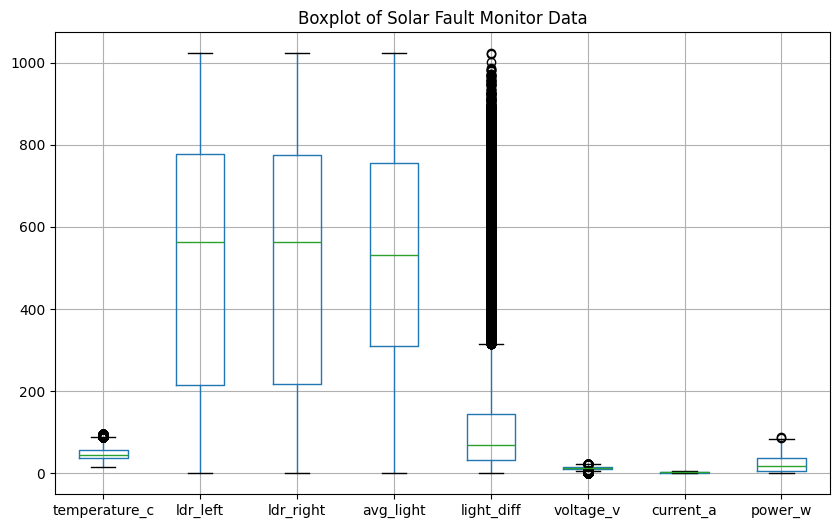

In [8]:
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Boxplot of Solar Fault Monitor Data')
plt.show()

## **Data Cleaning**

In [9]:
df.rename(columns={'label': 'fault_type'}, inplace=True)

In [10]:
LABEL_MAP = {
    'NORMAL': 0, 'LOW_LIGHT': 1, 'SHADOW': 2,
    'OVERHEAT': 3, 'PANEL_FAULT': 4
}

df['fault_type'] = df['fault_type'].map(LABEL_MAP)
df.head(10)

,temperature_c,ldr_left,ldr_right,avg_light,light_diff,voltage_v,current_a,power_w,fault_type,split
0,69.74,841.98,891.24,866.61,49.26,15.37,3.57,54.8709,3,train
1,39.65,481.20,425.65,453.42,55.55,15.37,1.17,17.9829,0,train
2,53.57,886.84,861.37,874.10,25.47,15.24,2.91,44.3484,0,train
3,38.30,317.65,206.12,261.88,111.53,15.61,0.00,0.0000,1,train
4,77.48,786.46,712.02,749.24,74.44,13.03,2.15,28.0145,3,train
5,44.78,682.27,616.87,649.57,65.40,2.82,3.76,10.6032,4,train
6,45.11,107.84,113.74,110.79,5.90,12.44,0.47,5.8468,1,test
7,43.01,442.64,376.30,409.47,66.34,19.47,0.10,1.9470,4,train
8,49.46,857.19,824.87,841.03,32.32,14.81,3.01,44.5781,0,validation
9,78.93,941.09,989.30,965.20,48.21,12.86,3.09,39.7374,3,train


### **Scaling the dataset into according to our hardwares**

In [11]:
df["power_w"] = df["voltage_v"] * df["current_a"]

max_voltage_target = 6.0
max_current_target = 0.2

df["voltage_v"] = df["voltage_v"] * (max_voltage_target / df["voltage_v"].max())
df["current_a"] = df["current_a"] * (max_current_target / df["current_a"].max())

# Recalculate power after scaling
df["power_w"] = df["voltage_v"] * df["current_a"]

### **Converting LDR (ANALOG to DIGITAL)**

In [12]:
# 500 above light below dark
threshold = 500

df["ldr_left"] = (df["ldr_left"] > threshold).astype(int)
df["ldr_right"] = (df["ldr_right"] > threshold).astype(int)

In [13]:
# Creating the avg_light and light_diff 
df["avg_light"] = (df["ldr_left"] + df["ldr_right"]) / 2
df["light_diff"] = abs(df["ldr_left"] - df["ldr_right"])

### **Add normalized features**

In [14]:
# make model independent of panel size
df["current_ratio"] = df["current_a"] / (df["voltage_v"] + 1e-5)
df["power_efficiency"] = df["power_w"] / (df["avg_light"] + 0.1)

### **Fixing dataset confilcts**

In [15]:
# RULE 1: No light → LOW_LIGHT
df.loc[df["avg_light"] == 0, "fault_type"] = 1

# RULE 2: Uneven light → SHADOW (PRIORITY)
df.loc[df["light_diff"] > 0, "fault_type"] = 2

# RULE 3: Light present + no power → PANEL_FAULT
df.loc[(df["avg_light"] == 1) & (df["power_w"] < 0.01), "fault_type"] = 4

# RULE 4: High temperature → OVERHEAT (ONLY if power exists)
df.loc[(df["temperature_c"] > 60) & (df["power_w"] > 0.01), "fault_type"] = 3

In [16]:
df.head(10)

,temperature_c,ldr_left,ldr_right,avg_light,light_diff,voltage_v,current_a,power_w,fault_type,split,current_ratio,power_efficiency
0,69.74,1,1,1.0,0,4.191818,0.119000,0.498826,3,train,0.028389,0.453479
1,39.65,0,0,0.0,0,4.191818,0.039000,0.163481,1,train,0.009304,1.634809
2,53.57,1,1,1.0,0,4.156364,0.097000,0.403167,0,train,0.023338,0.366516
3,38.30,0,0,0.0,0,4.257273,0.000000,0.000000,1,train,0.000000,0.000000
4,77.48,1,1,1.0,0,3.553636,0.071667,0.254677,3,train,0.020167,0.231525
5,44.78,1,1,1.0,0,0.769091,0.125333,0.096393,4,train,0.162961,0.087630
6,45.11,0,0,0.0,0,3.392727,0.015667,0.053153,1,test,0.004618,0.531527
7,43.01,0,0,0.0,0,5.310000,0.003333,0.017700,1,train,0.000628,0.177000
8,49.46,1,1,1.0,0,4.039091,0.100333,0.405255,0,validation,0.024841,0.368414
9,78.93,1,1,1.0,0,3.507273,0.103000,0.361249,3,train,0.029367,0.328408


In [17]:
print(df[df["power_w"] < 0.01][["avg_light", "fault_type"]].value_counts())

avg_light  fault_type
0.0        1             4021
1.0        4              917
0.5        2              514
Name: count, dtype: int64


In [18]:
df.to_csv('../data/solar_fault_monitor_preprocessed.csv', index=False)
print("Dataset saved correctly")

Dataset saved correctly
